In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

%matplotlib widget
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)

DATA_DIR = Path('.')
BACKUP_DIR = Path('../../eedmLabDashboard/backups')

In [24]:
# --- Load data logger txt files ---
def load_txt(path):
    # col 0 = row index, cols 1-5 = Time, Celsius, Humidity, Dew Point, Serial
    # index_col=0 uses the row numbers as the index
    # rename by position to avoid encoding issues with the degree symbol in header
    df = pd.read_csv(path, index_col=0, encoding='latin-1')
    cols = df.columns.tolist()
    df = df.rename(columns={cols[0]: 'time', cols[1]: 'temp_C', cols[2]: 'humidity_rh'})
    df['time'] = pd.to_datetime(df['time'])
    return df[['time', 'temp_C', 'humidity_rh']]

df_mar   = load_txt(DATA_DIR / '71A 2026Mar.txt')
df_mar06 = load_txt(DATA_DIR / '71A 2026Mar06.txt')

print('71A 2026Mar.txt   :', df_mar['time'].iloc[0], '->', df_mar['time'].iloc[-1], f'({len(df_mar)} pts)')
print('71A 2026Mar06.txt :', df_mar06['time'].iloc[0], '->', df_mar06['time'].iloc[-1], f'({len(df_mar06)} pts)')

71A 2026Mar.txt   : 2026-03-03 15:49:41 -> 2026-03-06 15:27:41 (12895 pts)
71A 2026Mar06.txt : 2026-03-06 16:00:00 -> 2026-03-09 14:27:40 (12684 pts)


In [25]:
# --- Load dashboard backup JSON files (March range) ---
def load_json_backup(path):
    with open(path) as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    df['time'] = pd.to_datetime(df['time'])
    return df

df_j08 = load_json_backup(BACKUP_DIR / 'data_2026-03-08.json')
df_j15 = load_json_backup(BACKUP_DIR / 'data_2026-03-15.json')

print('data_2026-03-08.json:', df_j08['time'].iloc[0], '->', df_j08['time'].iloc[-1], f'({len(df_j08)} pts)')
print('data_2026-03-15.json:', df_j15['time'].iloc[0], '->', df_j15['time'].iloc[-1], f'({len(df_j15)} pts)')

data_2026-03-08.json: 2026-02-28 22:20:04 -> 2026-03-08 23:50:04 (1152 pts)
data_2026-03-15.json: 2026-03-07 20:00:03 -> 2026-03-15 23:50:03 (1152 pts)


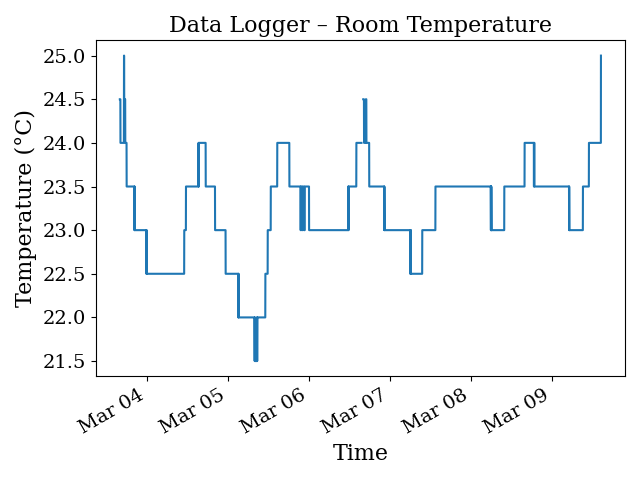

In [26]:
# --- Figure 1: Data logger (txt files) ---
plt.figure()
plt.plot(df_mar['time'],   df_mar['temp_C'],   color='C0', label='data logger')
plt.plot(df_mar06['time'], df_mar06['temp_C'], color='C0')
plt.title('Data Logger – Room Temperature')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gcf().autofmt_xdate()
#plt.legend()
plt.tight_layout()
plt.show()


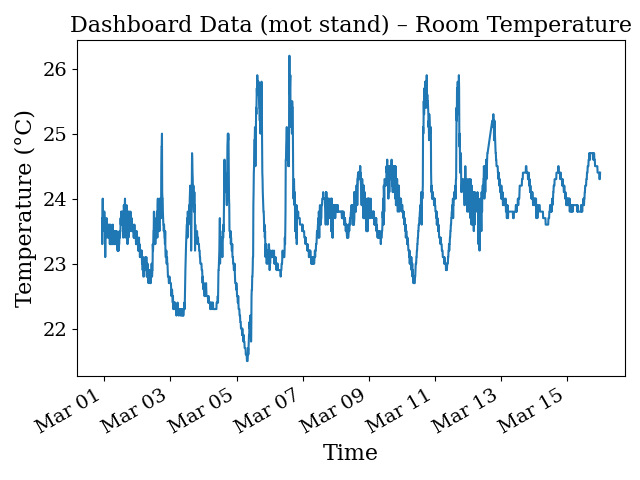

In [20]:
# --- Figure 2: Dashboard data (mot stand) – JSON backups ---
plt.figure()
plt.plot(df_j08['time'], df_j08['temp'], color='C0', label='dashboard data (mot stand)')
plt.plot(df_j15['time'], df_j15['temp'], color='C0')
plt.title('Dashboard Data (mot stand) – Room Temperature')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


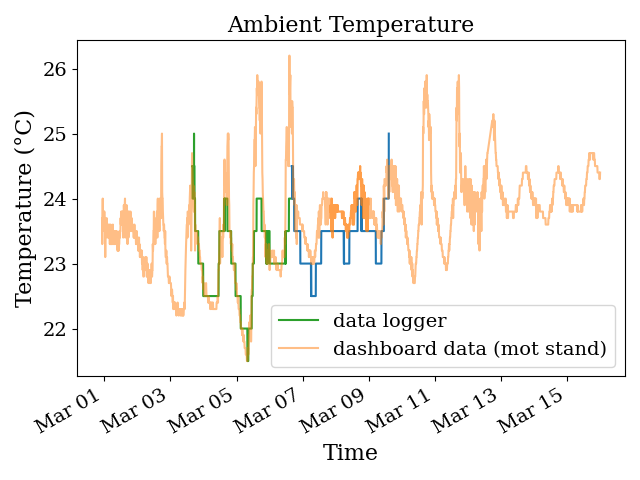

In [ ]:
# --- Figure 3: Overplot both sources ---
plt.figure()
plt.plot(df_mar['time'],   df_mar['temp_C'],   color='C0', label='data logger')
plt.plot(df_mar06['time'], df_mar06['temp_C'], color='C0')
plt.plot(df_j08['time'],   df_j08['temp'],     color='C1', label='dashboard data (mot stand)', alpha = .5)
plt.plot(df_j15['time'],   df_j15['temp'],     color='C1', alpha = .5)
plt.title('Ambient Temperature')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gcf().autofmt_xdate()
plt.legend()
plt.tight_layout()
plt.show()

